In [42]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [43]:
img=Image.open('Images\closeup-shot-purple-flower.jpg')

X_img=np.array(img)

pixels=X_img.reshape(-1,3)
pixels=pixels/255

In [44]:
print(pixels.shape)

(24000000, 3)


In [55]:
def centroids_init(X,K):
  rand_idx=np.random.permutation(X.shape[0])
  cents=X[rand_idx[:K]]
  return cents

In [46]:
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    K = centroids.shape[0]

    idx = np.zeros(m, dtype=np.int32)

    min_dist = np.full(m, np.inf)

    for k in range(K):
        d = np.sum((X - centroids[k]) ** 2, axis=1)

        mask = d < min_dist

        min_dist[mask] = d[mask]
        idx[mask] = k

    return idx

In [47]:
def compute_centroids(X,idx,K):
  m,n=X.shape

  centroids = np.zeros((K,n))

  np.add.at(centroids,idx,X)

  counts=np.bincount(idx,minlength=K).reshape(K,1)

  centroids[counts[:,0]>0]/=counts[counts[:,0]>0]
  

  return centroids


In [48]:
def kmeans(X,initial_centroids,iterations):
  m,n=X.shape
  K=initial_centroids.shape[0]
  centroids=initial_centroids
  prev_centroids=initial_centroids
  idx=np.zeros(m)

  for i in range(iterations):
    print('K-MEANS ITERATION %d/%d' %(i+1,iterations))

    idx=find_closest_centroids(X,centroids)

    centroids=compute_centroids(X,idx,K)
  
  return centroids,idx

In [ ]:
K=16
max_iterations=10

initial_centroids=centroids_init(pixels,K)

centroids,idx=kmeans(pixels,initial_centroids,max_iterations)

K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10


In [50]:
X_recovered=centroids[idx,:]

X_recovered=np.reshape(X_recovered,X_img.shape)

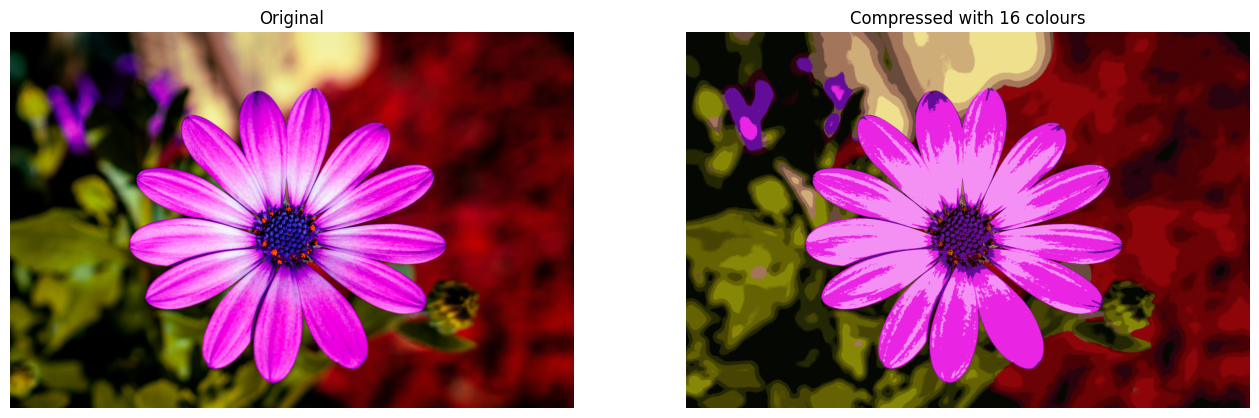

In [51]:
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(X_img)
ax[0].set_title('Original')
ax[0].set_axis_off()



ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()

In [53]:
def compute_cost(X,centroids,idx):

    cost=0

    for k in range(centroids.shape[0]):

        pts= X[idx==k]

        if len(pts)>0:
            cost+=np.sum((pts-centroids[k])**2)
    
    return cost/X.shape[0]


In [60]:
K_value = range(1,33)

cost_elbow=[]

for K in K_value:
    print("Running the Algorithm for K = ",K)

    initial_centroids=centroids_init(pixels,K)

    centroids,idx=kmeans(pixels,initial_centroids,10)

    cost_elbow.append(compute_cost(pixels,centroids,idx))

Running the Algorithm for K =  1
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running the Algorithm for K =  2
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running the Algorithm for K =  3
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running the Algorithm for K =  4
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERAT

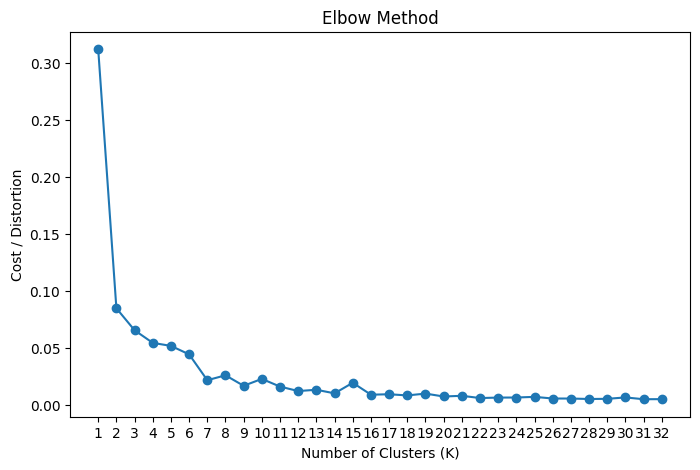

In [61]:
plt.figure(figsize=(8,5))

plt.plot(K_value, cost_elbow, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost / Distortion")
plt.title("Elbow Method")

plt.xticks(K_value)

plt.show()